In [29]:
 import pandas as pd 
 import seaborn as sns
 from matplotlib import pyplot as plt
 from sklearn.model_selection import train_test_split
 from sklearn.linear_model import LinearRegression
 from sklearn.metrics import r2_score
 from sklearn.preprocessing import StandardScaler
 
 analysis = pd.read_csv("delhi-weather-aqi-2025.csv")


In [30]:
analysis.tail()

,date_ist,time_ist,location,lat,lon,temp_c,humidity,pressure_mb,windspeed_kph,condition_text,description,aqi_index,pm2_5,pm10,co,no2
52555,31/12/2025,19:00,IGI Airport,28.5562,77.1,15.0,88,984.3,7.5,Mainly clear,WMO Code 1,209,148.5,149.0,1517,109.6
52556,31/12/2025,20:00,IGI Airport,28.5562,77.1,14.4,90,984.7,6.6,Partly cloudy,WMO Code 2,209,153.7,154.1,1637,112.5
52557,31/12/2025,21:00,IGI Airport,28.5562,77.1,13.8,92,985.1,5.8,Partly cloudy,WMO Code 2,209,149.5,149.9,1601,100.9
52558,31/12/2025,22:00,IGI Airport,28.5562,77.1,13.4,94,985.1,6.0,Overcast,WMO Code 3,209,146.7,147.1,1476,80.2
52559,31/12/2025,23:00,IGI Airport,28.5562,77.1,13.3,95,985.1,6.5,Partly cloudy,WMO Code 2,208,142.0,142.0,1354,61.5


In [31]:
analysis.isna().sum()

date_ist          0
time_ist          0
location          0
lat               0
lon               0
temp_c            0
humidity          0
pressure_mb       0
windspeed_kph     0
condition_text    0
description       0
aqi_index         0
pm2_5             0
pm10              0
co                0
no2               0
dtype: int64

as this dataset is already cleaned , it has no null values.

In [32]:
analysis["date_ist"] = pd.to_datetime(analysis["date_ist"], format="%d/%m/%Y")
analysis["month"] = analysis["date_ist"].dt.month
analysis_grouped = analysis.groupby("date_ist")
numeric_cols = analysis.select_dtypes(include=["float64", "int64","int32"]).columns
daily_avg = analysis_grouped[numeric_cols].mean().reset_index()
daily_avg["seasons"] = daily_avg["month"].apply(lambda x: 'Winter' if x in [12,1,2] else ('Summer' if x in [3,4,5] else ('Monsoon' if x in [6,7,8,9] else 'post-monsoon')))
analysis["seasons"] = analysis["month"].apply(lambda x: 'Winter' if x in [12,1,2] else ('Summer' if x in [3,4,5] else ('Monsoon' if x in [6,7,8,9] else 'post-monsoon')))
print(daily_avg.seasons.unique())


<StringArray>
['Winter', 'Summer', 'Monsoon', 'post-monsoon']
Length: 4, dtype: str


89.5424315068493


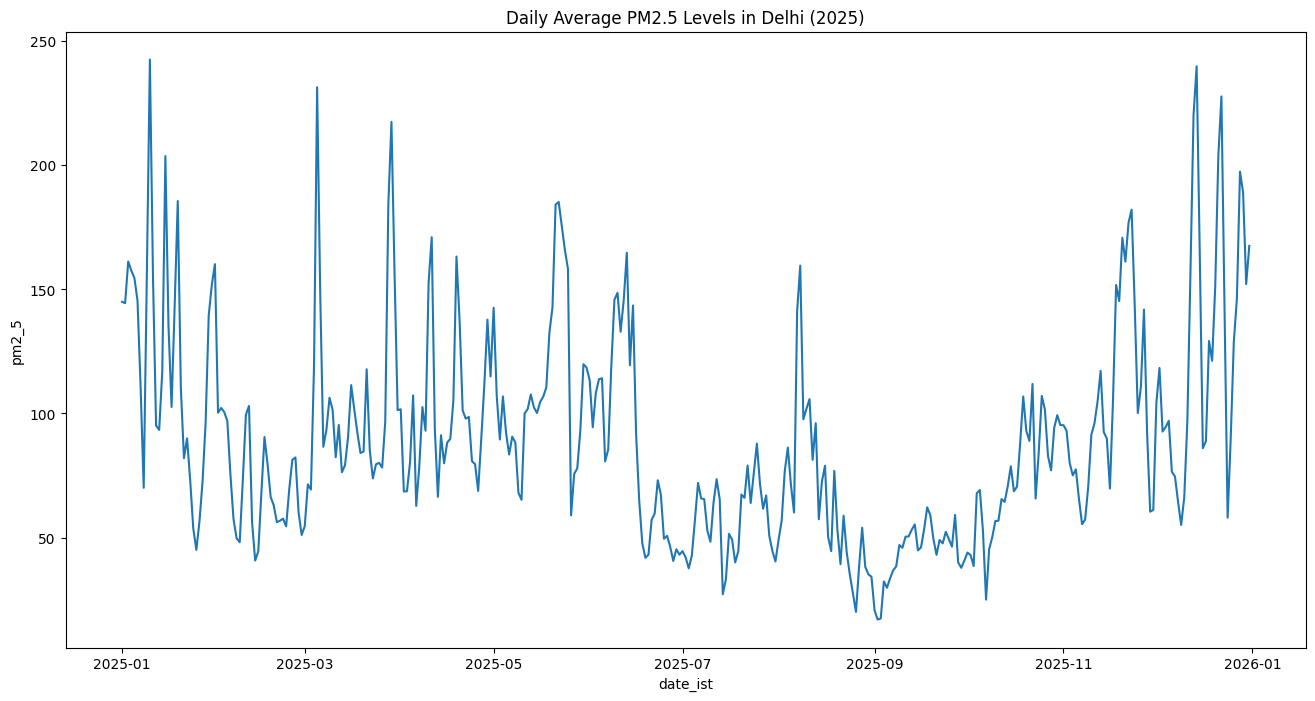

In [33]:
plt.figure(figsize=(16,8))
plt.title("Daily Average PM2.5 Levels in Delhi (2025)")
sns.lineplot(data=daily_avg, x="date_ist", y="pm2_5")
print(daily_avg["pm2_5"].mean())

The lineplot  tells us about the variation of pm2.5 values with the time of the year 

        seasons       pm2_5
0       Monsoon   63.583333
1        Summer  105.344339
2        Winter  109.284954
3  post-monsoon   88.499932
        seasons      pm2_5
0       Monsoon  53.158333
1        Summer  97.337500
2        Winter  96.946875
3  post-monsoon  84.154167
          location  min    max       mean
0      Anand Vihar  6.0  369.7  80.314783
1  Connaught Place  6.0  369.7  80.314783
2           Dwarka  6.0  443.3  98.770080
3      IGI Airport  6.0  443.3  98.770080
4  Okhla Phase III  6.0  443.3  98.770080
5           Rohini  6.0  369.7  80.314783


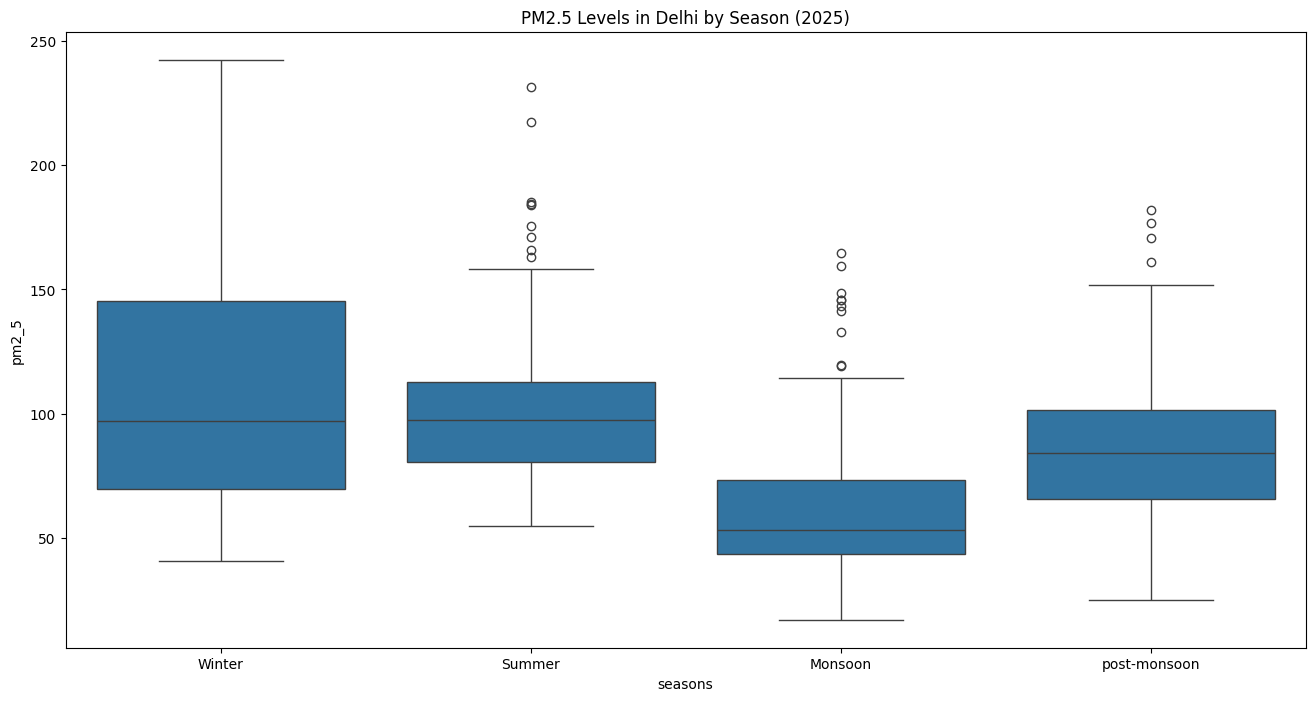

In [41]:
plt.figure(figsize=(16,8))
plt.title("PM2.5 Levels in Delhi by Season (2025)")
sns.boxplot(data=daily_avg, x="seasons", y="pm2_5")
station_avg = analysis.groupby("location")["pm2_5"].agg(['min','max','mean']).reset_index()
seasonal_avg = daily_avg.groupby("seasons")["pm2_5"].mean().reset_index()
seasonal_median = daily_avg.groupby("seasons")["pm2_5"].median().reset_index()
# station_quantile = analysis.groupby("location")["pm2_5"].quantile([0.01]).unstack().reset_index()
print(seasonal_avg)
print(seasonal_median)
print(station_avg)
# print(station_quantile)

In [42]:
analysis[["location", "lat", "lon"]].drop_duplicates()

,location,lat,lon
0,Anand Vihar,28.6469,77.3160
24,Connaught Place,28.6304,77.2177
48,Dwarka,28.5882,77.0494
72,Okhla Phase III,28.5273,77.2618
96,Rohini,28.7041,77.1025
120,IGI Airport,28.5562,77.1000


In [43]:
analysis.groupby("location")["date_ist"].count()

location
Anand Vihar        8760
Connaught Place    8760
Dwarka             8760
IGI Airport        8760
Okhla Phase III    8760
Rohini             8760
Name: date_ist, dtype: int64

In [45]:
locs = analysis["location"].unique()
for i in range(len(locs)):
    for j in range(i+1, len(locs)):
        a = analysis[analysis["location"]==locs[i]].sort_values("date_ist")["pm2_5"].reset_index(drop=True)
        b = analysis[analysis["location"]==locs[j]].sort_values("date_ist")["pm2_5"].reset_index(drop=True)
        match = (a == b).mean()
        if match > 0.9:
            print(locs[i], locs[j], match)

Anand Vihar Connaught Place 1.0
Anand Vihar Rohini 1.0
Connaught Place Rohini 1.0
Dwarka Okhla Phase III 1.0
Dwarka IGI Airport 1.0
Okhla Phase III IGI Airport 1.0


Data quality note: PM2.5 readings are identical across two groups of 3 stations each (Anand Vihar/Connaught Place/Rohini; Dwarka/Okhla Phase III/IGI Airport), confirmed via pairwise comparison. This indicates only 2 distinct PM2.5 series in the source dataset, not 6. Station-level PM2.5 comparisons are therefore not used in this analysis; seasonal and regression findings, which aggregate across all rows, are unaffected.

Text(0, 0.5, 'PM2.5')

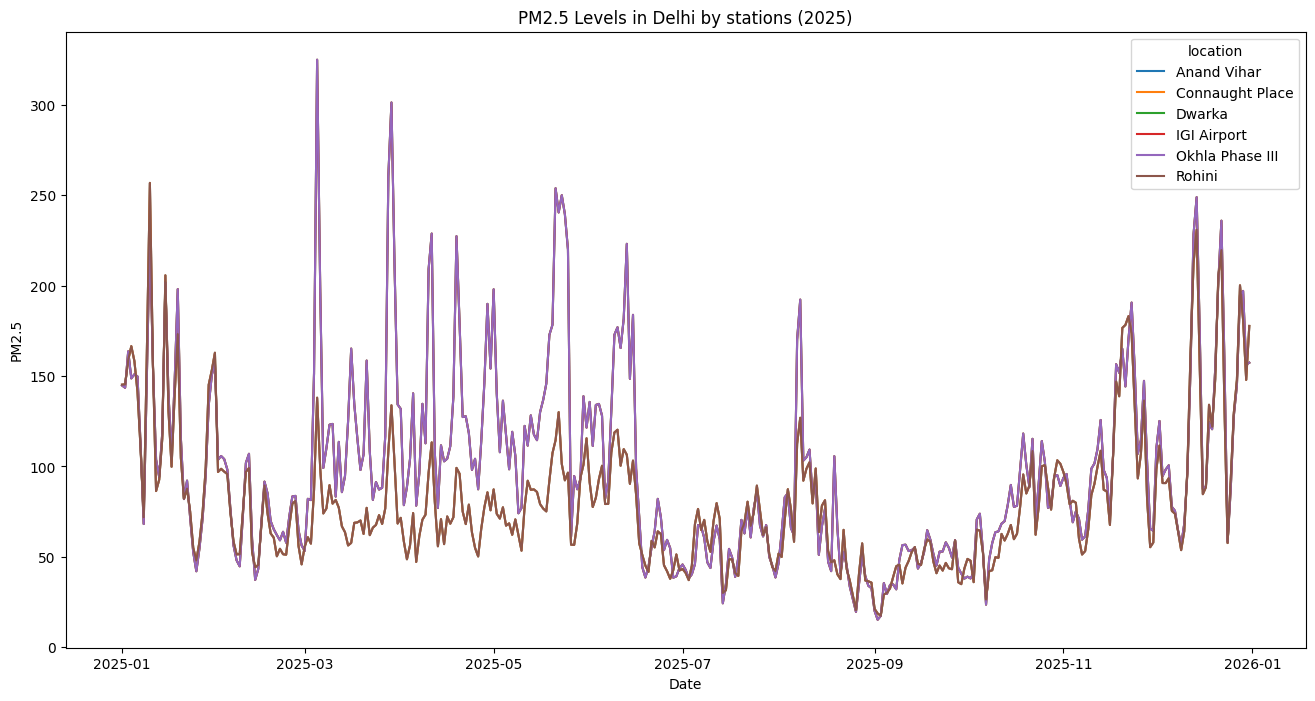

In [35]:
plt.figure(figsize=(16,8))
plt.title("PM2.5 Levels in Delhi by stations (2025)")
sns.lineplot(analysis.groupby(['date_ist', 'location'], as_index=False)['pm2_5'].mean(), x="date_ist", y="pm2_5", hue="location")
plt.xlabel("Date")
plt.ylabel("PM2.5")

The boxplot tells us the variation of pm2.5 particles with the seasons

<Axes: title={'center': 'Correlation Heatmap of Numeric Features in Delhi AQI Dataset (2025)'}>

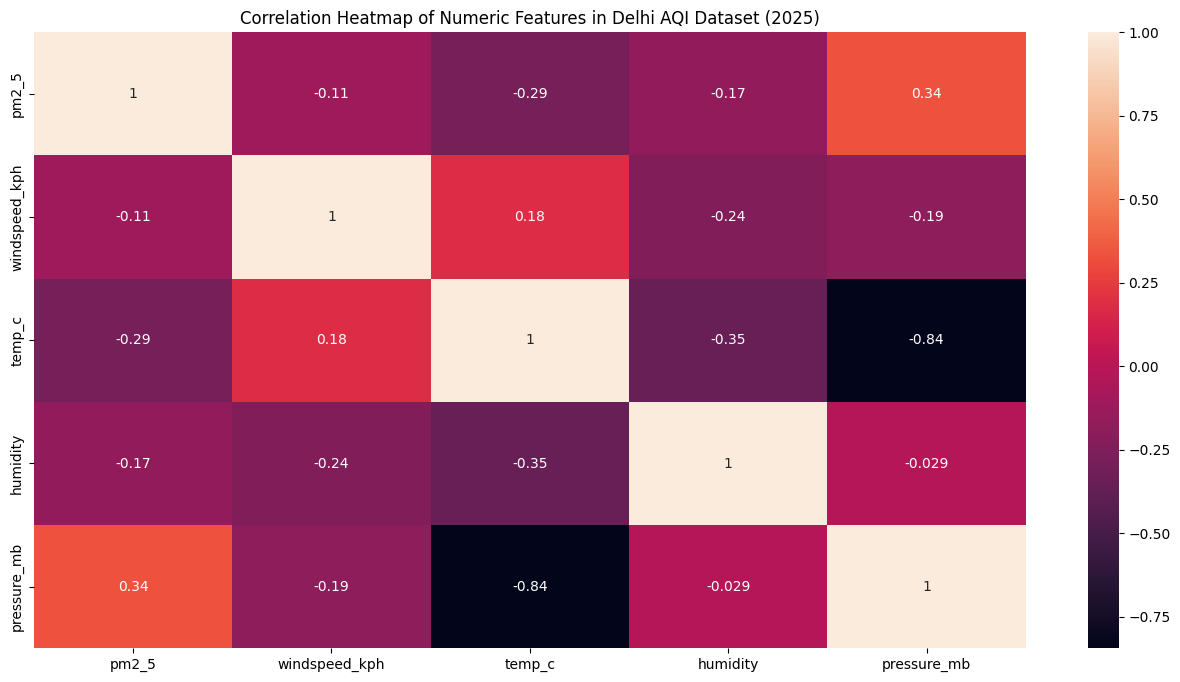

In [39]:
# print(analysis[numeric_cols].dtypes)
plt.figure(figsize=(16,8))
plt.title("Correlation Heatmap of Numeric Features in Delhi AQI Dataset (2025)")
sns.heatmap(daily_avg[["pm2_5","windspeed_kph","temp_c","humidity","pressure_mb"]].corr(), annot=True)

This heatmap tells us about the correlation between different weather parameters

<Axes: title={'center': 'Scatterplot of PM2.5 vs Windspeed in Delhi (2025)'}, xlabel='windspeed_kph', ylabel='pm2_5'>

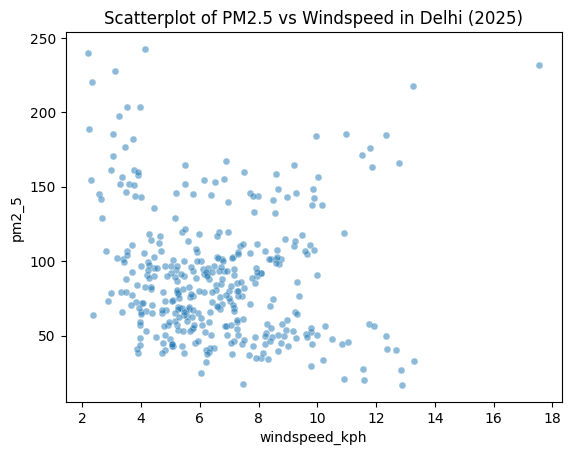

In [37]:
plt.Figure(figsize=(16,8))
plt.title("Scatterplot of PM2.5 vs Windspeed in Delhi (2025)")
sns.scatterplot(data=daily_avg,x="windspeed_kph",y="pm2_5",s=25,alpha=0.5)


In [38]:


x=daily_avg[["windspeed_kph","temp_c","humidity","pressure_mb"]]
y=daily_avg["pm2_5"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)
X_scaled = pd.DataFrame(X_scaled, columns=x.columns)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

importance = pd.Series(model.coef_, index=x.columns).sort_values(key=abs, ascending=False)
print(importance)
print(f"R²: {r2}")

temp_c          -18.663909
humidity        -16.540317
pressure_mb      -4.825016
windspeed_kph    -4.746645
dtype: float64
R²: 0.17379455654926412


Weather variables (temperature, wind speed, humidity, pressure) explain only ~12.3% of PM2.5 variance. Temperature shows the strongest negative relationship, consistent with Delhi's winter inversion effect trapping pollutants in cold air. Wind speed also negatively correlates with PM2.5 as expected. Humidity's negative coefficient is stronger and less intuitive, likely reflecting its dual role as both a fog-inversion proxy and a monsoon/rain proxy that pull PM2.5 in opposite directions. The low R² indicates that non-weather factors — vehicular emissions, crop-residue burning, construction dust — are the dominant drivers of Delhi's PM2.5, not weather alone.

**The three findings about this dataset so far:**

1) 24-hr average PM2.5 (~89.5µg/m³) is ~6x the WHO guideline and ~1.5x the Indian NAAQS standard  
2) Weather variables jointly explain only ~17% of PM2.5 variance (R²=0.174), with temperature the strongest single predictor — meaning non-meteorological sources (traffic, construction, crop burning) are the dominant driver of Delhi's PM2.5, not weather
3) Winter and summer both post high PM2.5 (109 vs 105) through different mechanisms — winter via inversion trapping, summer via dust/heat resuspension — while monsoon is the clear low (63.6), pending an n-check.